#### Screen the labeled data

I have approx 600 labeled snippets from approx 150 different news articles, hand coded by Xioaron and sent to me on 7 of April 2026

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fname = r"C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labeling\labeled_data_n154.xlsx"
training = pd.read_excel(fname)
training = training[['Text', 'Source', 'Codes', 'Number of Codes']]
training.head(2)


,Text,Source,Codes,Number of Codes
0,But many Indonesian politicians charge that mi...,urn:contentItem:5B82-9KB1-JDJN-625Y-00000-00.txt,Actor categories: Government 1A: central gover...,2
1,The Indonesian Chamber of Commerce and Industr...,urn:contentItem:5B82-9KB1-JDJN-625Y-00000-00.txt,Actor categories: Local community & workers 3A...,2


Category distribution (relative %):
           category        pct
0  Actor categories  38.777372
1    Conflict types  30.383212
2    Character Role  29.470803
3      Policy Tools   0.729927
4      Overall tone   0.638686

Top codes per category (relative % within category):
            category                                               code  \
4   Actor categories       Government 1A: central government/presindent   
1   Actor categories                              Chinese firms/SOEs 2A   
11  Actor categories                       Local community & workers 3A   
3   Actor categories                                  Chinese worker 2D   
2   Actor categories                              Chinese government 2C   
5   Actor categories  Government 1B: local government (provincial/re...   
8   Actor categories   International companies & foreign investments 4B   
9   Actor categories                        International government 4C   
6   Actor categories           Indonesian compani

C:\Users\charlott\AppData\Local\Temp\ipykernel_16580\4162919928.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_freq_plot, x='pct', y='category', palette='viridis')


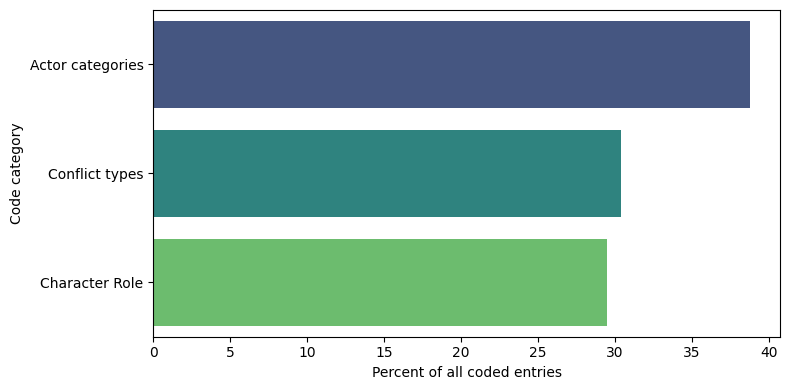

C:\Users\charlott\AppData\Local\Temp\ipykernel_16580\4162919928.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


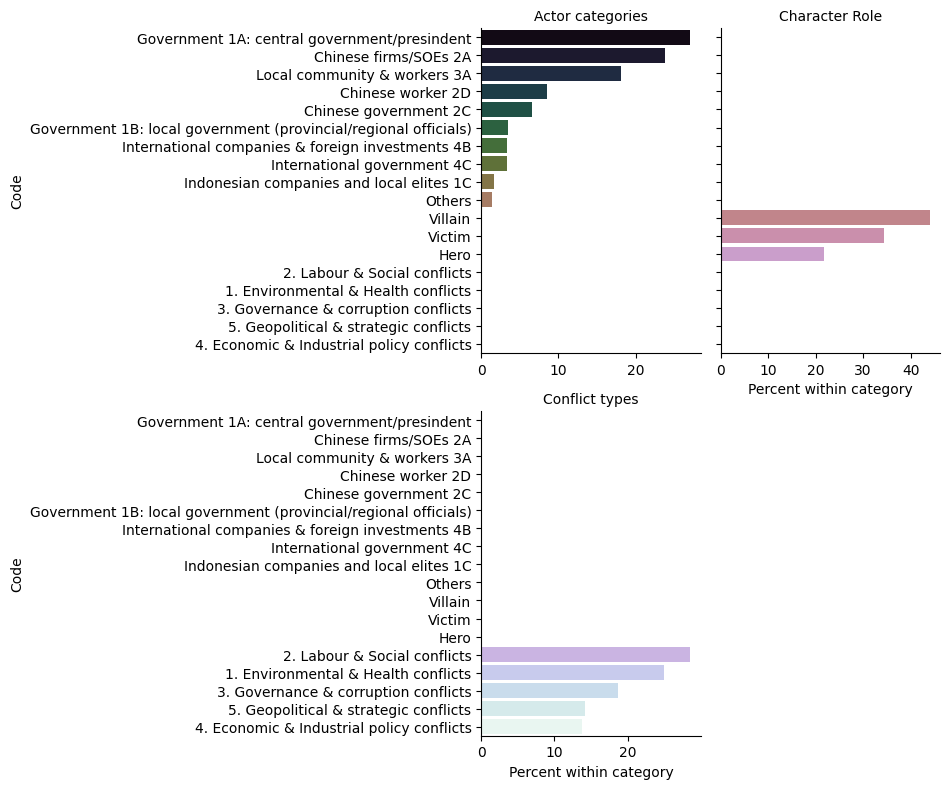

In [2]:
# parse the Codes field into category + code rows
codes_series = training['Codes'].dropna()
rows = []
for cell in codes_series:
    for part in str(cell).split(','):
        code_str = part.strip()
        if not code_str:
            continue
        if ':' in code_str:
            cat_code = code_str.split(':', 1)
            category = cat_code[0].strip()
            code_label = cat_code[1].strip()
        elif '\u2013' in code_str:
            # "Villain – X" entries: already covered by "Character Role: Villain" in the same row, skip
            continue
        else:
            category = 'Unknown'
            code_label = code_str
        rows.append({'category': category, 'code': code_label})

codes_df = pd.DataFrame(rows)

# relative frequency by category
category_freq = codes_df['category'].value_counts(normalize=True).mul(100).reset_index()
category_freq.columns = ['category', 'pct']

# relative frequency by code within each category
code_freq = (
    codes_df
    .groupby(['category', 'code'])
    .size()
    .reset_index(name='count')
)
code_freq['pct_within_category'] = code_freq.groupby('category')['count'].transform(lambda x: x / x.sum() * 100)

# top codes per category (top 10 for plotting clarity)
top_codes = (
    code_freq
    .sort_values(['category', 'count'], ascending=[True, False])
    .groupby('category')
    .head(10)
)

# quick inspection
print("Category distribution (relative %):")
print(category_freq)
print("\nTop codes per category (relative % within category):")
print(top_codes)

# exclude non-focus categories from visualizations
EXCLUDE_CATS = {'Policy Tools', 'Overall tone'}
category_freq_plot = category_freq[~category_freq['category'].isin(EXCLUDE_CATS)]
top_codes_plot     = top_codes[~top_codes['category'].isin(EXCLUDE_CATS)]

# visualization
plt.figure(figsize=(8, 4))
sns.barplot(data=category_freq_plot, x='pct', y='category', palette='viridis')
plt.xlabel('Percent of all coded entries')
plt.ylabel('Code category')
plt.tight_layout()
plt.show()

# per-category code frequency (top 10 each)
g = sns.catplot(
    data=top_codes_plot,
    x='pct_within_category',
    y='code',
    col='category',
    kind='bar',
    col_wrap=2,
    sharex=False,
    height=4,
    aspect=1.2,
    palette='cubehelix'
)
g.set_titles('{col_name}')
g.set_axis_labels('Percent within category', 'Code')
plt.tight_layout()
plt.show()

## Which code categories work for ML training?

Of the 589 labeled snippets, three categories have enough examples to train on: Actor categories (396 snippets), Character Role (323), and Conflict types (319). All five conflict sub-types have between 46 and 95 examples, which is workable. Actor categories are strong overall but a few rare sub-codes (under 10 examples) should be merged or dropped.

Overall tone (55 snippets) and Policy Tools (61 snippets, heavily skewed) are too sparse to be useful. We focus on the three strong categories going forward.

Note: entries coded as `Villain – X` were merged into `Character Role: Villain` since every such row already had that label anyway.

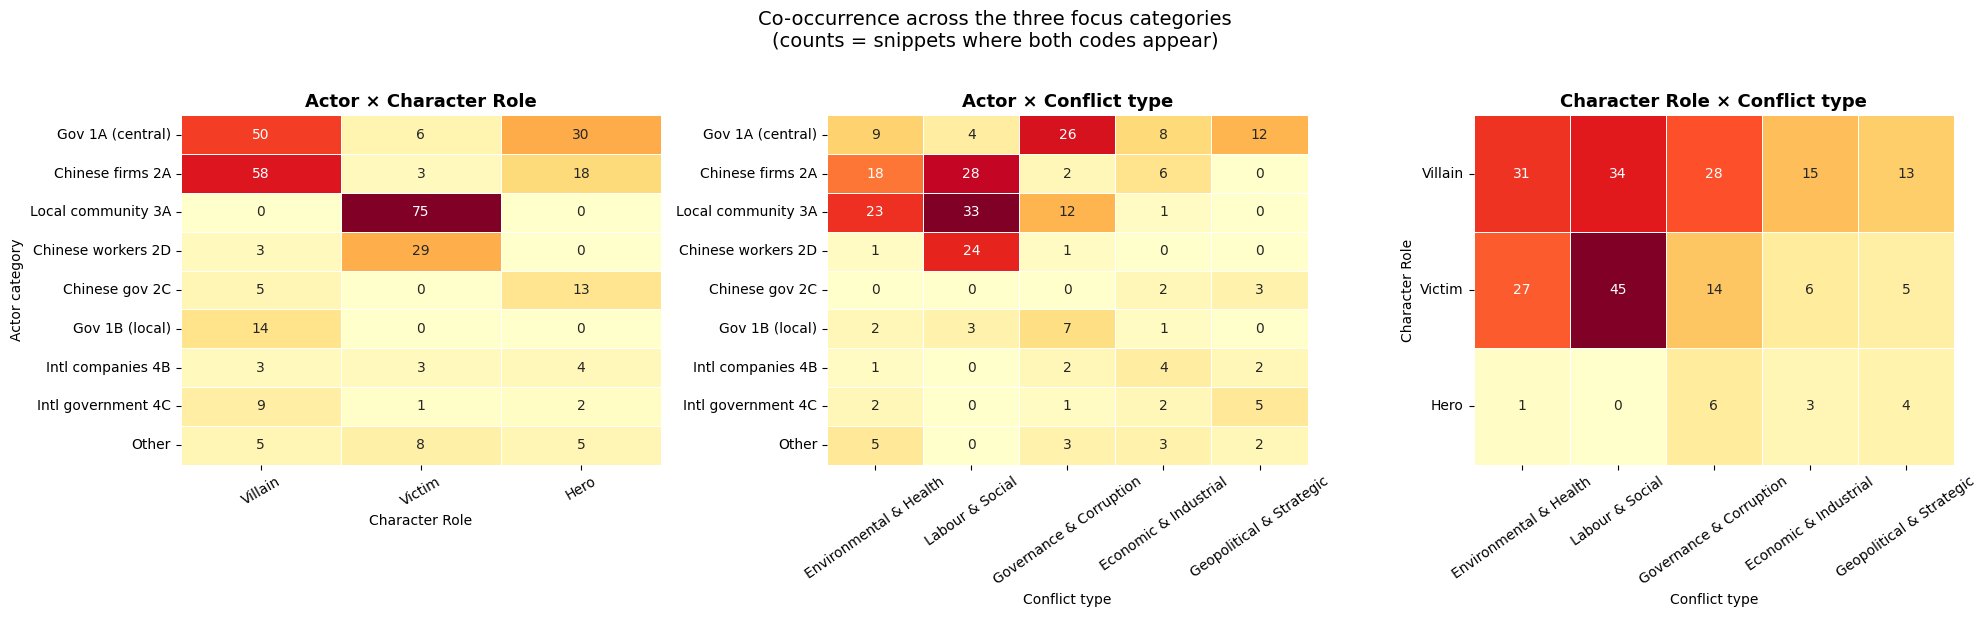

In [3]:
from itertools import product

# --- label shortening ---
actor_rename = {
    'Government 1A: central government/presindent': 'Gov 1A (central)',
    'Chinese firms/SOEs 2A':                        'Chinese firms 2A',
    'Local community & workers 3A':                 'Local community 3A',
    'Chinese worker 2D':                            'Chinese workers 2D',
    'Chinese government 2C':                        'Chinese gov 2C',
    'Government 1B: local government (provincial/regional officials)': 'Gov 1B (local)',
    'International companies & foreign investments 4B': 'Intl companies 4B',
    'International government 4C':                  'Intl government 4C',
}
ACTOR_KEEP = list(actor_rename.values())  # ≥10 examples; rest → "Other"

conflict_rename = {
    '1. Environmental & Health conflicts':      'Environmental & Health',
    '2. Labour & Social conflicts':             'Labour & Social',
    '3. Governance & corruption conflicts':     'Governance & Corruption',
    '4. Economic & Industrial policy conflicts':'Economic & Industrial',
    '5. Geopolitical & strategic conflicts':    'Geopolitical & Strategic',
}

focus = {'Actor categories', 'Character Role', 'Conflict types'}

def parse_snippet(cell):
    out = {'Actor categories': [], 'Character Role': [], 'Conflict types': []}
    for part in str(cell).split(','):
        code_str = part.strip()
        if not code_str or '\u2013' in code_str:
            continue
        if ':' in code_str:
            cat, label = code_str.split(':', 1)
            cat, label = cat.strip(), label.strip()
            if cat == 'Actor categories':
                label = actor_rename.get(label, 'Other')
                out['Actor categories'].append(label)
            elif cat == 'Character Role':
                out['Character Role'].append(label)
            elif cat == 'Conflict types':
                label = conflict_rename.get(label, label)
                out['Conflict types'].append(label)
    return out

snippets = [parse_snippet(c) for c in training['Codes'].dropna()]

ACTORS    = ACTOR_KEEP + ['Other']
ROLES     = ['Villain', 'Victim', 'Hero']
CONFLICTS = list(conflict_rename.values())

def cooccurrence(snippets, cat_a, labels_a, cat_b, labels_b):
    mat = pd.DataFrame(0, index=labels_a, columns=labels_b)
    for s in snippets:
        for a, b in product(set(s[cat_a]), set(s[cat_b])):
            if a in mat.index and b in mat.columns:
                mat.loc[a, b] += 1
    return mat

mat_ar = cooccurrence(snippets, 'Actor categories', ACTORS,    'Character Role', ROLES)
mat_ac = cooccurrence(snippets, 'Actor categories', ACTORS,    'Conflict types', CONFLICTS)
mat_rc = cooccurrence(snippets, 'Character Role',   ROLES,     'Conflict types', CONFLICTS)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

kw = dict(annot=True, fmt='d', linewidths=0.5, cbar=False)

sns.heatmap(mat_ar, ax=axes[0], cmap='YlOrRd', **kw)
axes[0].set_title('Actor × Character Role', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Role')
axes[0].set_ylabel('Actor category')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(mat_ac, ax=axes[1], cmap='YlOrRd', **kw)
axes[1].set_title('Actor × Conflict type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Conflict type')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

sns.heatmap(mat_rc, ax=axes[2], cmap='YlOrRd', **kw)
axes[2].set_title('Character Role × Conflict type', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Conflict type')
axes[2].set_ylabel('Character Role')
axes[2].tick_params(axis='x', rotation=35)
axes[2].tick_params(axis='y', rotation=0)

plt.suptitle('Co-occurrence across the three focus categories\n(counts = snippets where both codes appear)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Key findings from the co-occurrence analysis

Looking at how actors and roles align, the clearest pattern is that the local community is almost exclusively a victim (75 out of 77 appearances), while Chinese firms are the dominant villain (58 out of 101). Central government is more ambivalent — cast as villain in 50 cases but also as hero in 30, which sets it apart from Chinese firms.

On conflict types, labour and social conflicts and environmental and health conflicts are where most of the action is. Local community and Chinese firms both cluster heavily in these two types, which makes sense given the victim–villain dynamic between them. Chinese workers are almost exclusively associated with labour conflicts. Central government stands out in governance and corruption conflicts, which is distinct from the other actors.

The hero role is rare across all conflict types and shows up most in governance, geopolitical, and economic/industrial contexts — suggesting heroes tend to appear in more institutional or political narratives rather than in grassroots conflict stories.

=== Word count summary ===
count    485.0
mean      61.9
std       32.3
min        9.0
25%       38.0
50%       58.0
75%       76.0
max      273.0
Name: Text, dtype: float64

Median: 58 words
<= 30 words :   61 snippets
31–100 words:  374 snippets
> 100 words :   50 snippets


C:\Users\charlott\AppData\Local\Temp\ipykernel_16580\3003480642.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


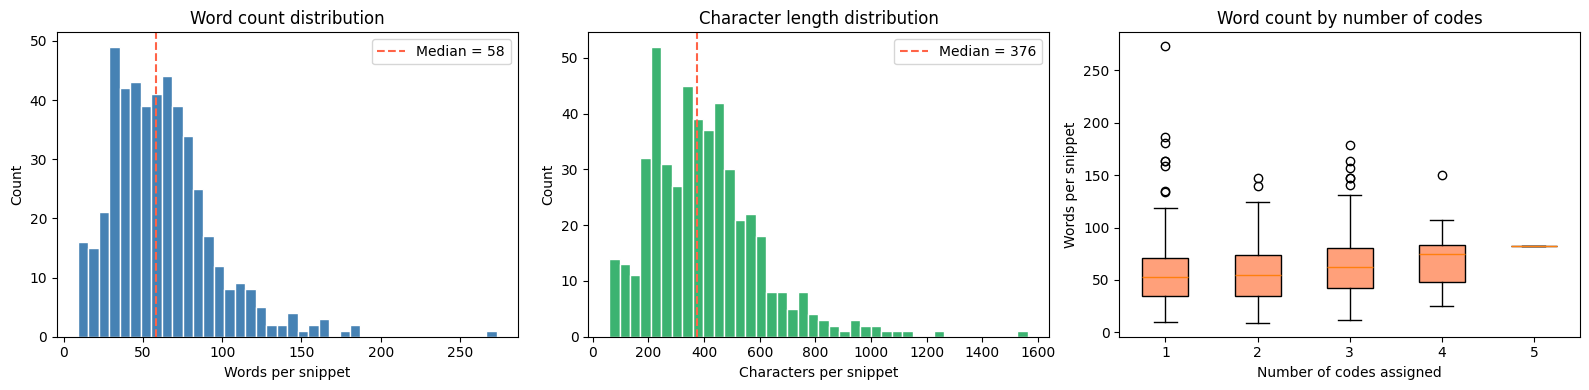

In [4]:
# ── Snippet structure analysis ──────────────────────────────────────────────
texts = training['Text'].dropna()

lengths_chars = texts.str.len()
lengths_words = texts.str.split().str.len()

# summary stats
print("=== Word count summary ===")
print(lengths_words.describe().round(1))
print(f"\nMedian: {lengths_words.median():.0f} words")
print(f"<= 30 words : {(lengths_words <= 30).sum():>4d} snippets")
print(f"31–100 words: {((lengths_words > 30) & (lengths_words <= 100)).sum():>4d} snippets")
print(f"> 100 words : {(lengths_words > 100).sum():>4d} snippets")

# ── plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. word count distribution
axes[0].hist(lengths_words, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(lengths_words.median(), color='tomato', linestyle='--', label=f'Median = {lengths_words.median():.0f}')
axes[0].set_title('Word count distribution')
axes[0].set_xlabel('Words per snippet')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. character length distribution
axes[1].hist(lengths_chars, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].axvline(lengths_chars.median(), color='tomato', linestyle='--', label=f'Median = {lengths_chars.median():.0f}')
axes[1].set_title('Character length distribution')
axes[1].set_xlabel('Characters per snippet')
axes[1].set_ylabel('Count')
axes[1].legend()

# 3. word count by number of codes assigned
labeled = training.dropna(subset=['Codes']).copy()
labeled['word_count'] = labeled['Text'].str.split().str.len()
labeled['Number of Codes'] = labeled['Number of Codes'].astype(int)

axes[2].boxplot(
    [labeled.loc[labeled['Number of Codes'] == n, 'word_count'].dropna()
     for n in sorted(labeled['Number of Codes'].unique())],
    labels=sorted(labeled['Number of Codes'].unique()),
    patch_artist=True,
    boxprops=dict(facecolor='lightsalmon')
)
axes[2].set_title('Word count by number of codes')
axes[2].set_xlabel('Number of codes assigned')
axes[2].set_ylabel('Words per snippet')

plt.tight_layout()
plt.show()

## preparation for NBA3: build the labeled training matrix: conflict types

Actor categories will be handled separately via NER. Character Role is set aside for now. We focus exclusively on the **5 Conflict type** classes, all of which have sufficient labeled examples (46–95 per class, no merging needed).

Each row = one snippet from `training` that has at least one conflict label. Binary indicator columns `conflict__X` are created for each of the 5 classes. Snippets with no conflict label are dropped.

In [5]:
# Read from the new conflicts_labeled_updated file
# Background is that Xioaran updated the coding to code more snippets for two categories we were struggling before.
conflicts_input = pd.read_excel(
    r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labeling\conflicts_labeled_updated.xlsx'
)

CONFLICT_LABELS = list(conflict_rename.values())

def extract_conflicts(cell):
    result = set()
    if pd.isna(cell):
        return result
    for part in str(cell).split(','):
        code_str = part.strip()
        if not code_str or '–' in code_str:
            continue
        if ':' in code_str:
            cat, label = code_str.split(':', 1)
            cat, label = cat.strip(), label.strip()
            if cat == 'Conflict types':
                result.add(conflict_rename.get(label, label))
    return result

rows = []
for _, row in conflicts_input.iterrows():
    found = extract_conflicts(row['Codes'])
    if not found:
        continue
    record = {
        'snippet'    : row['Text Content'],
        'article_id' : row['Source'],
    }
    for c in CONFLICT_LABELS:
        record[f'conflict__{c}'] = int(c in found)
    rows.append(record)

conflicts = pd.DataFrame(rows)

print(f"Total rows in conflicts_labeled_updated : {len(conflicts_input)}")
print(f"Rows with conflict labels (kept)        : {len(conflicts)}")
print(f"Rows dropped (no conflict label)        : {len(conflicts_input) - len(conflicts)}")
conflict_cols = [f'conflict__{c}' for c in CONFLICT_LABELS]
print(f"\nLabel distribution:")
print(conflicts[conflict_cols].sum().sort_values(ascending=False).to_string())
print(f"\nSnippets with multiple conflict labels: {(conflicts[conflict_cols].sum(axis=1) > 1).sum()}")
print(f"Snippets with exactly one label       : {(conflicts[conflict_cols].sum(axis=1) == 1).sum()}")

# save for use in other notebooks
# standardize column names for ML
RENAME_CONFLICTS = {
    'conflict__Environmental & Health'  : 'env_health',
    'conflict__Labour & Social'         : 'labour_social',
    'conflict__Governance & Corruption' : 'governance_corruption',
    'conflict__Economic & Industrial'   : 'economic_industrial',
    'conflict__Geopolitical & Strategic': 'geopolitical_strategic',
}
conflicts = conflicts.rename(columns=RENAME_CONFLICTS)

OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflicts_labeled.csv'
conflicts.to_csv(OUT, index=False)
print(f"\nSaved to: {OUT}")

conflicts.head(3)

Total rows in conflicts_labeled_updated : 559
Rows with conflict labels (kept)        : 390
Rows dropped (no conflict label)        : 169

Label distribution:
conflict__Labour & Social             97
conflict__Environmental & Health      88
conflict__Economic & Industrial       75
conflict__Governance & Corruption     73
conflict__Geopolitical & Strategic    66

Snippets with multiple conflict labels: 8
Snippets with exactly one label       : 382

Saved to: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\conflicts_labeled.csv


,snippet,article_id,env_health,labour_social,governance_corruption,economic_industrial,geopolitical_strategic
0,But many Indonesian politicians charge that mi...,urn:contentItem:5B82-9KB1-JDJN-625Y-00000-00.txt,0,0,0,1,0
1,"Ganjar Pranowo, the former governor of Central...",urn:contentItem:6B65-5GJ1-F12F-F11R-00000-00.txt,0,0,1,0,0
2,"Large-scale projects faced scrutiny, with envi...",urn:contentItem:6B65-5GJ1-F12F-F11R-00000-00.txt,1,0,0,0,0


In [6]:
import re

CB_PATH = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labeling\Codebook_Actor_Roles_Conflicts.xlsx'
actor_def = pd.read_excel(CB_PATH, sheet_name='actors_definition', nrows=14)

def parse_examples(cell):
    """Split semicolon-separated examples into a clean list of named entities."""
    if pd.isna(cell):
        return []
    return [e.strip() for e in str(cell).split(';') if e.strip()]

def parse_cues(cell):
    """Split semicolon-separated textual cues into a list of trigger phrases."""
    if pd.isna(cell):
        return []
    return [c.strip() for c in str(cell).split(';') if c.strip()]

ner_records = []
for _, row in actor_def.iterrows():
    if pd.isna(row['actor']):
        continue
    ner_records.append({
        'actor_label'     : str(row['actor']).strip(),
        'definition'      : str(row['definition']).strip() if not pd.isna(row['definition']) else '',
        'named_entities'  : parse_examples(row['examples']),
        'trigger_phrases' : parse_cues(row['textual cues']),
        'exclude_notes'   : str(row['exclude']).strip() if not pd.isna(row['exclude']) else '',
    })

ner_codebook = pd.DataFrame(ner_records)
print(ner_codebook[['actor_label','named_entities','trigger_phrases']].to_string(index=False))

# save CSV (lists as semicolon-joined strings) and JSON (preserves lists)
OUT_DIR = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training'
csv_df = ner_codebook.copy()
csv_df['named_entities']  = csv_df['named_entities'].apply(lambda x: '; '.join(x))
csv_df['trigger_phrases'] = csv_df['trigger_phrases'].apply(lambda x: '; '.join(x))
csv_df.to_csv(OUT_DIR + r'\ner_actor_codebook.csv', index=False)

import json as _json
_json.dump(ner_records, open(OUT_DIR + r'\ner_actor_codebook.json', 'w', encoding='utf-8'),
           ensure_ascii=False, indent=2)
print(f'\nSaved: ner_actor_codebook.csv + .json')


                                                            actor_label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  named_entities                                                                                                                                                                                                                                                                                trigger_phrases
                                                 

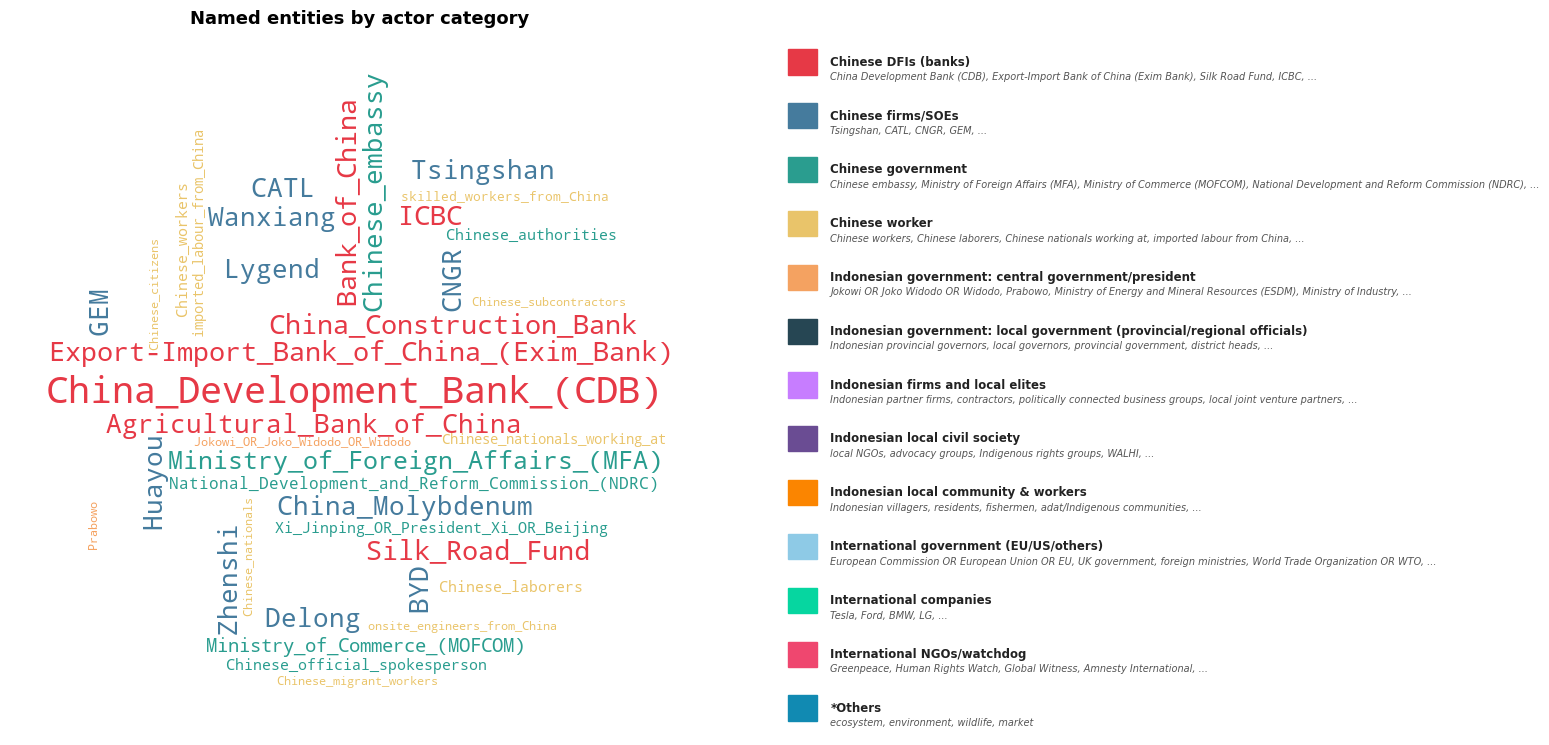

Saved: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\ner_entities_wordcloud.png


In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PALETTE = [
    '#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261',
    '#264653','#c77dff','#6a4c93','#fb8500','#8ecae6',
    '#06d6a0','#ef476f','#118ab2'
]

# replace spaces with underscores so multi-word entities stay as one token
entity_to_color = {}
for i, rec in enumerate(ner_records):
    col = PALETTE[i % len(PALETTE)]
    for ent in rec['named_entities']:
        key = ent.replace(' ', '_')
        entity_to_color[key] = col

# equal weight so no entity dominates by length
freq = {k: 10 for k in entity_to_color}

def color_func(word, **kwargs):
    return entity_to_color.get(word, '#555555')

# circular mask
x, y = np.ogrid[:700, :700]
mask = 255 * ((x - 350)**2 + (y - 350)**2 > 320**2).astype(np.uint8)

wc = WordCloud(
    width=700, height=700,
    background_color='white',
    mask=mask,
    color_func=color_func,
    max_words=300,
    prefer_horizontal=0.55,
    collocations=False,
    min_font_size=9,
    max_font_size=44,
).generate_from_frequencies(freq)

fig = plt.figure(figsize=(15, 7))
ax_wc  = fig.add_axes([0.0,  0.0, 0.55, 1.0])
ax_leg = fig.add_axes([0.56, 0.0, 0.44, 1.0])

ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.axis('off')
ax_wc.set_title('Named entities by actor category', fontsize=13,
                 fontweight='bold', pad=8)

# legend: colored square + category name + entity list
ax_leg.axis('off')
n = len(ner_records)
row_h = 1.0 / n
for i, rec in enumerate(ner_records):
    col  = PALETTE[i % len(PALETTE)]
    y0   = 1.0 - (i + 0.5) * row_h
    ax_leg.add_patch(plt.Rectangle((0.0, y0 - 0.018), 0.045, 0.036,
                                    color=col, transform=ax_leg.transAxes,
                                    clip_on=False))
    ax_leg.text(0.065, y0, rec['actor_label'],
                transform=ax_leg.transAxes,
                fontsize=8.5, va='center', fontweight='bold', color='#222')
    entities_str = ', '.join(rec['named_entities'][:4])
    if len(rec['named_entities']) > 4:
        entities_str += ', ...'
    ax_leg.text(0.065, y0 - row_h * 0.28, entities_str,
                transform=ax_leg.transAxes,
                fontsize=7, va='center', color='#555', style='italic')

OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\ner_entities_wordcloud.png'
plt.savefig(OUT, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}')
